# Prototype

## Model Base


1.   Inputs

*   
*   List item


2.   Functions



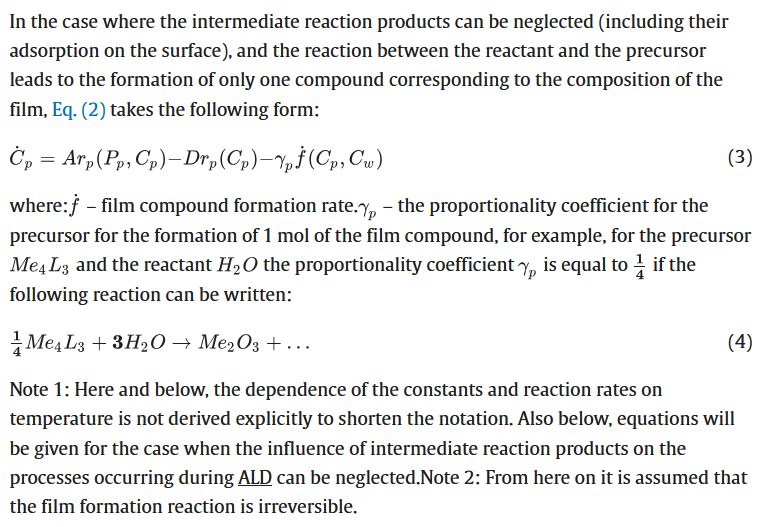

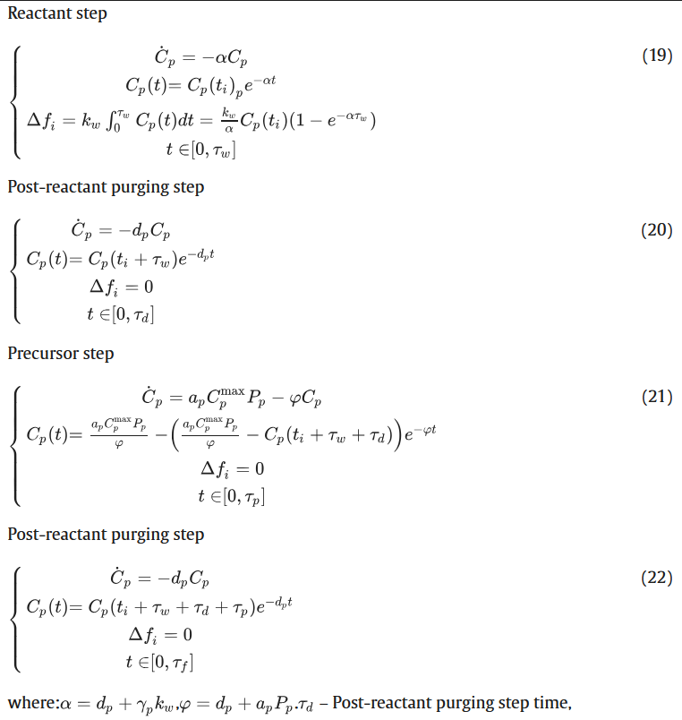

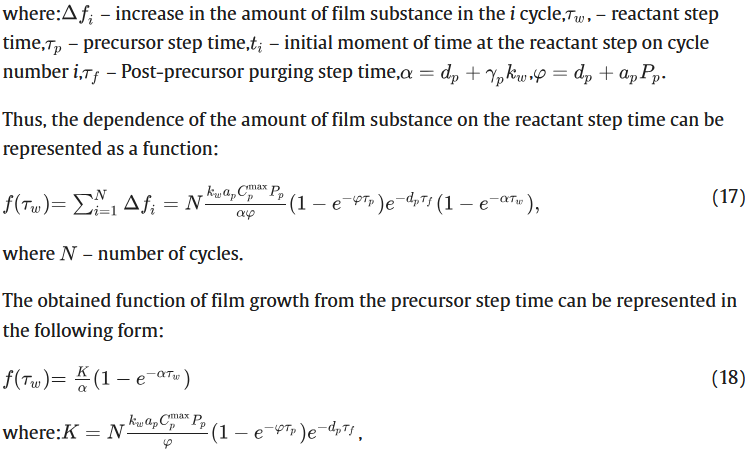

## Model Dependence


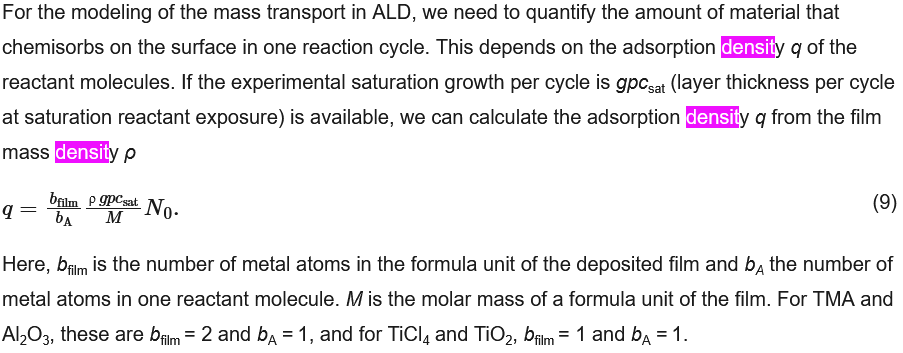

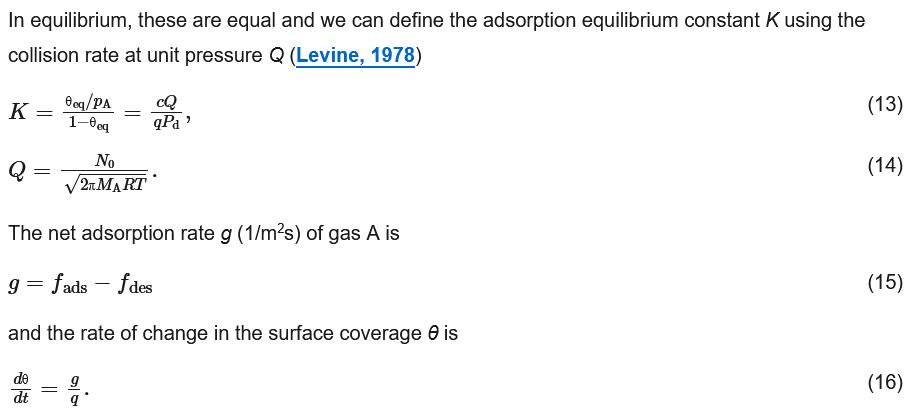

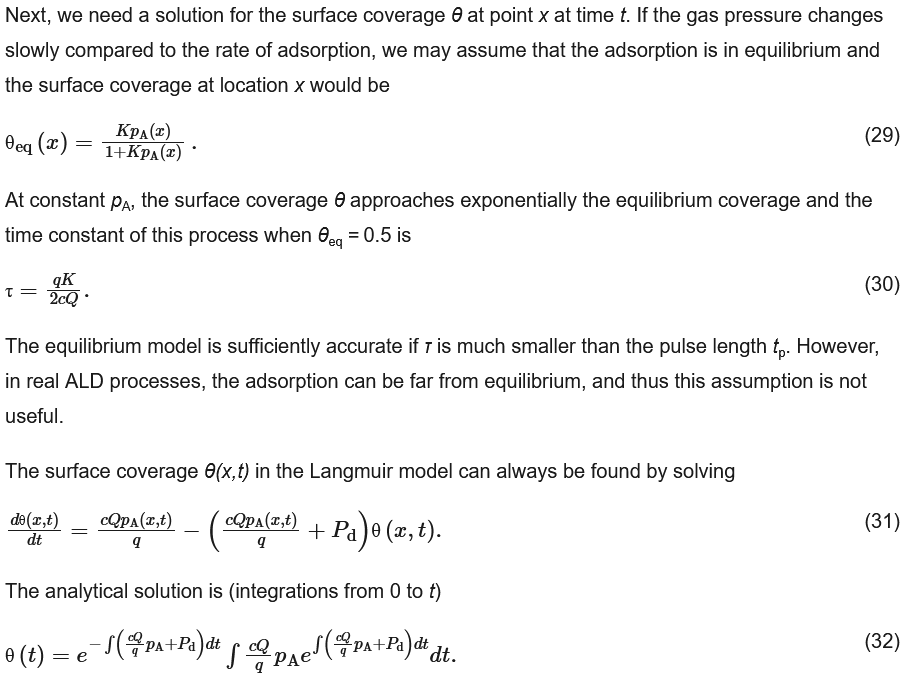

In [1]:
!pip install torchdiffeq

In [2]:
import torch
import torch.nn as nn

from torchdiffeq import odeint
import matplotlib.pyplot as plt

In [3]:
import numpy as np
import matplotlib.pyplot as plt

N0 = 6.22*10**23
k = 1.38*10**-23 # Boltzmann constant
R = 8.314 # J/K.mol

T = 300 + 273 # Temperature
M = 101.96/1000 # kg/mol (molar mass)
gpc = 106 * 10**-12 # gpc (m)

c = 0.01 # c = sticking probability
Pd = 0 # Pd = Desorption probability

Pa = 100#*1e-3 # Partial Pressure of reactant A (limiting diffusion)
Pb = 300 # partial pressure of reactant B

rho = 3.99*1000 #density of film material
t_p = 0.1 #pulse time
K = 100 # equilibrium constant for langmuir model

q = (2/1) * (rho*gpc/M) * N0 #TMA q (adsorption density)
Q = N0/np.sqrt(2*np.pi* M * R * T)# Q = collisons/unit pressure

# Channel Geometry
H = 0.5e-6
W = 0.1e-3

h = 2/(1/H + 1/W)

# Molar Mass
MA = 72.09e-3 #kg/mol
MB = 18e-3


In [4]:
# def f(t,z):
#     return c*Q*Pa/q - (c*Q*Pa/q + Pd)*z

# z0 = torch.Tensor([0])
# t = torch.linspace(0,20,1000)
# out = odeint(f, z0, t);

In [5]:
plt.plot(t, out, 'go--')
ax2 = plt.twinx()
ax2.plot(t, np.cumsum(out)*gpc, 'ro--')
plt.grid()
plt.show()

NameError: name 't' is not defined

In [ ]:
#may be better fitting the 'd' values
def d_estimate(MA, rho):
    #rho here is the fluid/solid density of the molecule
    return 2* np.pow(3*MA/(4*np.pi*rho*N0), 1/3)

def za(da, db, MA, MB, pA, pB):
    #find collision rate of a; (A+B) collisions and A+A collisions
    #molecular diameter, molar mass, partial pressure
    return (np.pi/4*((da+db)**2)*np.sqrt(8*R*T/np.pi*(1/MA + 1/MB)) * pB + np.pi * da**2 * np.sqrt(16*R*T/(np.pi*MA))*pA) /(R*T)

def Deff(da, db, MA, MB, pA, pB):
    z_a = za(da, db, MA, MB, pA, pB)
    va = np.sqrt(8*R*T/(np.pi * MA))
    Da = 3*np.pi/16 * va**2/z_a
    Dkn = h*np.sqrt(8*R*T/(9*np.pi*MA))
    Deff = 1/(1/Da + 1/Dkn)
    return Deff

# Channel approximation

In [ ]:
def approx(x, t, Deff, pA0, last_theta):
    D = pA0*Deff*H/(q*k*T*(1-np.log(K*pA0+1)/(K*pA0)))
    xs = np.sqrt(D*t)
    delim = np.sqrt((h*N0*Deff)/(4*R*T*c*Q))
    xt = xs-delim#np.max(0.0, xs-delim)
    if xt < 0:
        xt = 0
    pt = pA0*(1-xt/xs)
    pA = pA0 * (1-x/xs)
    pA[x>xt] = pt*np.exp(-(x[x>xt]-xt)/(xs-xt))

    theta = (K*pA)/(1+K*pA)

    next_theta = last_theta + theta

    thickness = gpc*next_theta

    #print('xt: ', xt)

    return thickness, next_theta, {'theta':theta, 'pA': pA}

In [ ]:
da = 591e-12 #tma #d_estimate()
db = 418e-12 #water #d_estimate()

Deff_step = Deff(da, db, MA, MB, pA=Pa, pB=Pb)

x = np.linspace(0, 200e-6, 100)
last_theta = np.zeros_like(x)
for i in range(100):
    result = approx(x, t=t_p, Deff=Deff_step, pA0=Pa, last_theta = last_theta)
    last_theta = result[1]
result_0 = np.copy(result[0])
for i in range(1000):
    result = approx(x, t=t_p, Deff=Deff_step, pA0=Pa, last_theta = last_theta)
    last_theta = result[1]
result_1 = np.copy(result[0])

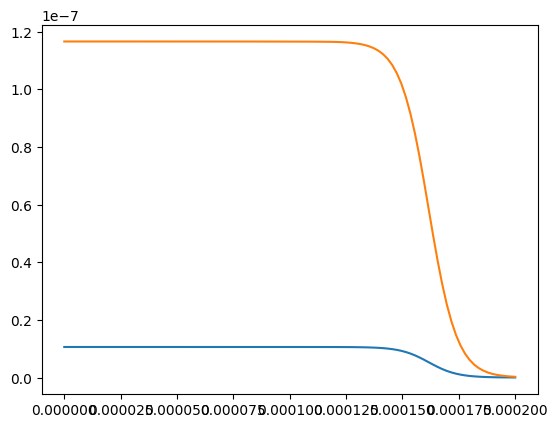

In [ ]:
plt.plot(x, result_0)
plt.plot(x, result_1)

## Hexagonal model

Text(0, 0.5, 'Thickness (nm)')

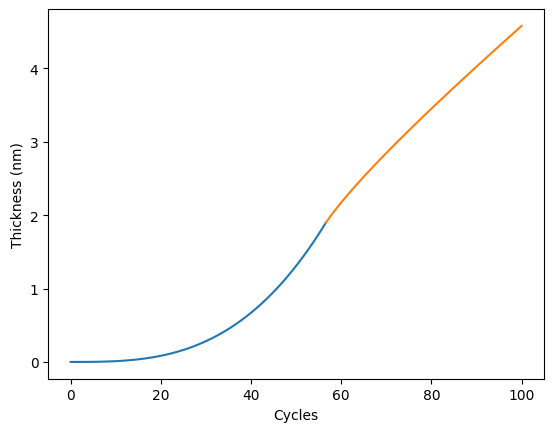

In [ ]:
Nd = 0.04
t = np.linspace(0, 100, 100)
r = t*0.05
Rcov = 1/np.sqrt(np.pi * Nd)
tcut = np.sum(r<Rcov)
plt.plot(t[:tcut+1], 2/3 *np.pi*Nd*(r[:tcut+1])**3)

t2 = t[tcut:]
r = r[tcut:]
plt.plot(t2, Nd * (np.pi*(Rcov**2)*np.sqrt(r**2 - Rcov**2)+np.pi/6*(3*Rcov**2+(r-np.sqrt(r**2-Rcov**2))**2)*(r-np.sqrt(r**2-Rcov**2))))
plt.xlabel('Cycles')
plt.ylabel('Thickness (nm)')

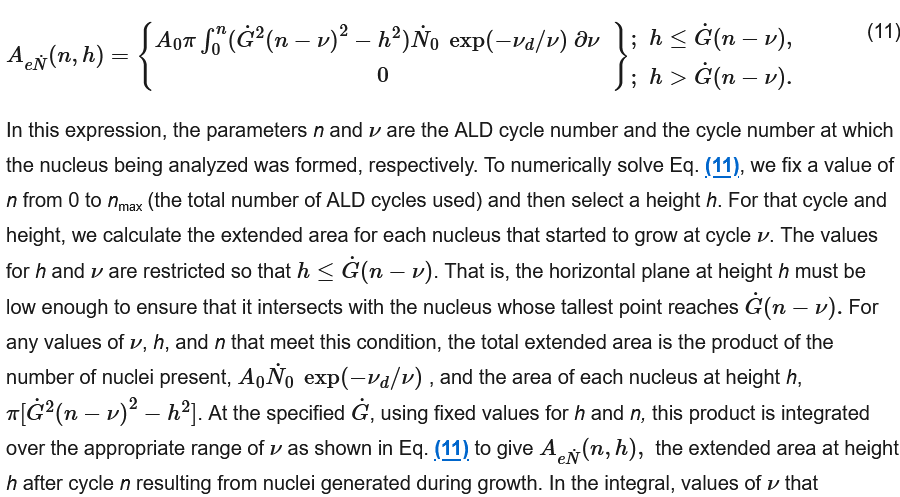

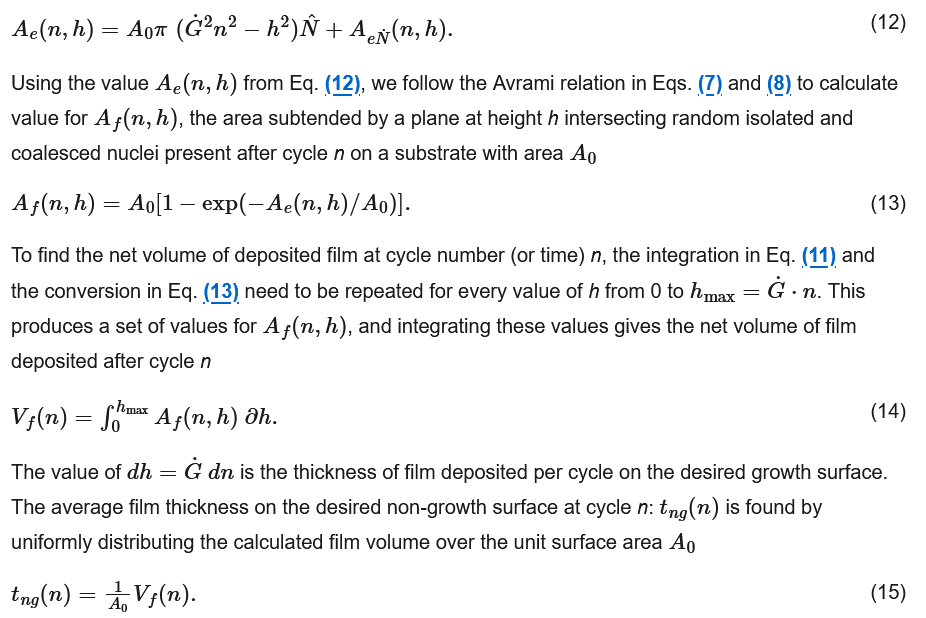

In [ ]:
import numpy as np
from scipy.integrate import quad

Gr = .1 # growth rate
vd = 0 # the characteristic number of cycles for nucleation incubation
Nn = .001 # density of initial nucleation sites
Nr0 = 0 # nucleation site generation rate
A0 = 100

def Aenx_1(v):
    return np.exp(-vd/v)*(n-v)**2
# def Aenx_2_a(v):
#     return np.exp(-vd/v)*((n-v)**2)
def Aenx_2b(v):
    return np.exp(-vd/v)

#t = torch.linspace(0,20,100)
#out = odeint(Aenx_1, torch.Tensor([n]), t)

P1 = []
P2 = []

for n in np.arange(400):
    #Aenx_1_  = quad(Aenx_1, 1e-6, n)[0]
    #Aenx_2_  = quad(Aenx_2b, 1e-6, n)[0] #quad(lambda v: Aenx_2(v, (h/Gr)**2), 1e-6, n)[0]

    Aenx1 = lambda dn: A0 * np.pi * Gr**2 * Nr0 * quad(lambda v: np.exp(-vd/v)*(dn-v)**2, 1e-6, dn)[0] #simple version
    Aenx2 = lambda h: A0 * np.pi * Gr**2 * Nr0 * (quad(Aenx_1, 1e-6, n-h/Gr)[0]-(h/Gr)**2*quad(Aenx_2b, 1e-6, n-h/Gr)[0]) #complex version

    Aenn1 = lambda dn: A0 * np.pi * (Gr*dn)**2 * Nn
    Aenn2 = lambda h: A0 * np.pi * ((Gr*n)**2-h**2) * Nn

    Aen1 = lambda dn: Aenx1(dn)+Aenn1(dn)
    Aen2 = lambda h: Aenx2(h)+Aenn2(h)

    Af1 = lambda dn: A0*(1-np.exp(-Aen1(dn)/A0))
    Af2 = lambda h: A0 * (1 - np.exp(-Aen2(h)/A0))

    Vf1 = quad(lambda dn: (2-Af1(dn)/A0)*Af1(dn)*Gr, 1e-6, n)[0]
    Vf2 = quad(Af2, 1e-6, Gr*n)[0]

    tf1 = Vf1/A0
    tf2 = Vf2/A0

    P1.append(tf1)
    P2.append(tf2)


In [ ]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Thickness (nm)')

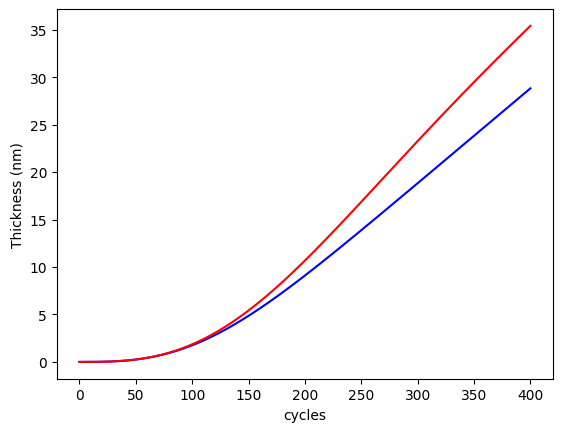

In [ ]:
#plt.plot(np.arange(len(Points)), 1-np.exp(-np.array(Points)/A0))
plt.plot(np.arange(len(P1)), P1, color='blue')
plt.plot(np.arange(len(P2)), P2, color='red')
plt.xlabel('cycles')
plt.ylabel('Thickness (nm)')

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# ------------------------------
# 1. Define your model (equation)
# ------------------------------
class EquationModel(nn.Module):
    def __init__(self):
        super().__init__()
        # parameters to learn
        self.a = nn.Parameter(torch.randn(1))
        self.b = nn.Parameter(torch.randn(1))
        self.c = nn.Parameter(torch.randn(1))

    def forward(self, x):
        return self.a * torch.sin(self.b * x) + self.c


model = EquationModel()

In [ ]:
import torch
import torch.nn as nn

#from torchdiffeq import odeint
#import math
import numpy as np

import matplotlib.pyplot as plt

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# ------------------------------
# 1. Define your model (equation)
# ------------------------------
class EquationModel(nn.Module):
    def __init__(self):
        super().__init__()
        # parameters to learn
        self.a = nn.Parameter(torch.randn(1))
        self.b = nn.Parameter(torch.randn(1))
        self.c = nn.Parameter(torch.randn(1))

    def forward(self, x):
        return self.a * torch.sin(self.b * x) + self.c


model = EquationModel()

# ------------------------------
# 2. Create sample data
# ------------------------------
# Example input data
x = torch.linspace(0, 2 * torch.pi, 200).unsqueeze(1)

# Example target (ground truth)
true_a, true_b, true_c = 2.0, 3.0, -1.0
y_true = true_a * torch.sin(true_b * x) + true_c

# ------------------------------
# 3. Choose optimizer + loss
# ------------------------------
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

# ------------------------------
# 4. Train
# ------------------------------
for step in range(2000):
    y_pred = model(x)
    loss = loss_fn(y_pred, y_true)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 200 == 0:
        print(f"step {step}, loss = {loss.item():.6f}")

# ------------------------------
# 5. Check learned parameters
# ------------------------------
print("Learned parameters:")
print("a =", model.a.item())
print("b =", model.b.item())
print("c =", model.c.item())


step 0, loss = 4.261868
step 200, loss = 1.872652
step 400, loss = 1.865061
step 600, loss = 1.863689
step 800, loss = 1.862887
step 1000, loss = 1.862263
step 1200, loss = 1.861765
step 1400, loss = 1.861361
step 1600, loss = 1.861028
step 1800, loss = 1.860749
Learned parameters:
a = 1.6483126878738403
b = -0.1285673826932907
c = -0.36986243724823


# Streamlined Model Design

## Pure Model Function

### Hex Model

In [ ]:
# Nd = 0.04
# t = np.linspace(0, 100, 100)
# r = t*0.05
# Rcov = 1/np.sqrt(np.pi * Nd)
# tcut = np.sum(r<Rcov)
# plt.plot(t[:tcut+1], 2/3 *np.pi*Nd*(r[:tcut+1])**3)

# t2 = t[tcut:]
# r = r[tcut:]
# plt.plot(t2, Nd * (np.pi*(Rcov**2)*np.sqrt(r**2 - Rcov**2)+np.pi/6*(3*Rcov**2+(r-np.sqrt(r**2-Rcov**2))**2)*(r-np.sqrt(r**2-Rcov**2))))
# plt.xlabel('Cycles')
# plt.ylabel('Thickness (nm)')

In [ ]:
import numpy as np

def hex_model(cycle, Nd = 0.04, delta_r=0.05):
    #t = np.linspace(0, 100, 100)
    cycle = np.array(cycle)
    radius = cycle*delta_r
    Rcov = 1/np.sqrt(np.pi * Nd)
    #tcut = np.sum(r<Rcov)
    result = np.zeros_like(cycle)
    lower = lambda r: 2/3 *np.pi*Nd*(r[r < Rcov])**3
    upper = lambda r: Nd * (np.pi*(Rcov**2)*np.sqrt((r)**2 - Rcov**2)+np.pi/6*(3*Rcov**2+(r-np.sqrt(r**2-Rcov**2))**2)*(r-np.sqrt(r**2-Rcov**2)))

    result[radius < Rcov] = lower(radius[radius < Rcov])
    result[radius >= Rcov] = upper(radius[radius >= Rcov])

    return result

### Avrami Model

In [ ]:
import numpy as np
from scipy.integrate import quad

# def Aenx_1(v):
#     return np.exp(-vd/v)*(n-v)**2
# def Aenx_2b(v):
#     return np.exp(-vd/v)

lower_limit = 1

def avrami_model(cycle,
                Gr = .1, # growth rate
                vd = 0, # the characteristic number of cycles for nucleation incubation
                Nn = .001, # density of initial nucleation sites
                Nr0 = 0, # nucleation site generation rate
                A0 = 100 # substrate area
                ):

    res = []
    cycle = np.array(cycle)
    for n in cycle:
        def Aenx_1(v):
            return np.exp(-vd/v)*(n-v)**2
        def Aenx_2b(v):
            return np.exp(-vd/v)
        Aenx1 = lambda dn: A0 * np.pi * Gr**2 * Nr0 * quad(lambda v: np.exp(-vd/v)*(dn-v)**2, lower_limit, dn)[0] #simple version

        Aenn1 = lambda dn: A0 * np.pi * (Gr*dn)**2 * Nn

        Aen1 = lambda dn: Aenx1(dn)+Aenn1(dn)

        Af1 = lambda dn: A0*(1-np.exp(-Aen1(dn)/A0))

        Vf1 = quad(lambda dn: (2-Af1(dn)/A0)*Af1(dn)*Gr, lower_limit, n)[0]

        tf1 = Vf1/A0

        res.append(tf1)

    return res

def avrami_model_2(cycle,
                    Gr = .1, # growth rate
                    vd = 0, # the characteristic number of cycles for nucleation incubation
                    Nn = .001, # density of initial nucleation sites
                    Nr0 = 0, # nucleation site generation rate
                    A0 = 100 # substrate area
                    ):


    res = []
    cycle = np.array(cycle)
    for n in cycle:
        #n = cycle
        def Aenx_1(v):
            return np.exp(-vd/v)*(n-v)**2
        def Aenx_2b(v):
            return np.exp(-vd/v)
        Aenx2 = lambda h: A0 * np.pi * Gr**2 * Nr0 * (quad(Aenx_1, lower_limit, n-h/Gr)[0]-(h/Gr)**2*quad(Aenx_2b, lower_limit, n-h/Gr)[0]) #complex version

        Aenn2 = lambda h: A0 * np.pi * ((Gr*n)**2-h**2) * Nn

        Aen2 = lambda h: Aenx2(h)+Aenn2(h)

        Af2 = lambda h: A0 * (1 - np.exp(-Aen2(h)/A0))

        Vf2 = quad(Af2, lower_limit, Gr*n)[0]

        tf2 = Vf2/A0

        res.append(tf2)

    return res



### Model Parameter Fit

In [ ]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
dataset = pd.read_csv('/content/drive/MyDrive/PSED Project/10_06_2025_10-59-11_simulation_data_155.0cy.csv', header=[0])
popt, pcov = curve_fit(avrami_model_2, dataset['Cycle'].values, dataset['Thickness (nm)'].values,
                        p0 = [.1, 1e-21, 1E-3, 1e-21, 100], bounds=([.08, 0, 1e-9, 0, 50], [.12, 1e-3, 1e-3, 1e-5, 150]))

plt.plot(dataset['Cycle'], dataset['Thickness (nm)'])
plt.plot(dataset['Cycle'], avrami_model_2(dataset['Cycle'].values, *popt))

/tmp/ipython-input-4031219093.py:56: RuntimeWarning: divide by zero encountered in scalar divide
  return np.exp(-vd/v)*(n-v)**2
/tmp/ipython-input-4031219093.py:58: RuntimeWarning: divide by zero encountered in scalar divide
  return np.exp(-vd/v)
/tmp/ipython-input-4031219093.py:59: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  Aenx2 = lambda h: A0 * np.pi * Gr**2 * Nr0 * (quad(Aenx_1, lower_limit, n-h/Gr)[0]-(h/Gr)**2*quad(Aenx_2b, lower_limit, n-h/Gr)[0]) #complex version
/tmp/ipython-input-4031219093.py:59: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  Aenx2 = lambda h: A0 * np.pi * Gr**2 * Nr0 * (quad(Aenx_1, lower_limit, n-h/Gr)[0]-(h/Gr)**2*quad(Aenx_2b, lower_limit, n-h/Gr)[0]) #complex version
/tmp/ipython-input-4031219093.py

ValueError: array must not contain infs or NaNs

In [ ]:
popt

array([1.0e-01, 1.5e+01, 1.0e-06, 0.0e+00, 3.0e+02])

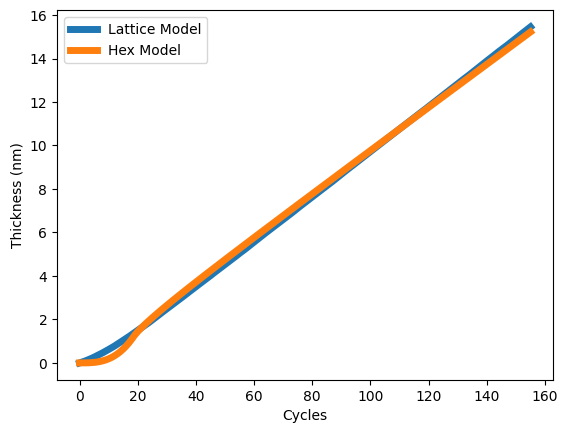

In [ ]:
dataset = pd.read_csv('/content/drive/MyDrive/PSED Project/10_06_2025_10-59-11_simulation_data_155.0cy.csv', header=[0])
popt_2, pcov_2 = curve_fit(hex_model, dataset['Cycle'].values, dataset['Thickness (nm)'].values,
                        p0 = [.04, 0.05])

plt.plot(dataset['Cycle'], dataset['Thickness (nm)'], label='Lattice Model', linewidth=5)
plt.plot(dataset['Cycle'], hex_model(dataset['Cycle'].values, *popt_2), label='Hex Model', linewidth=5)
plt.xlabel('Cycles')
plt.ylabel('Thickness (nm)')
plt.legend()

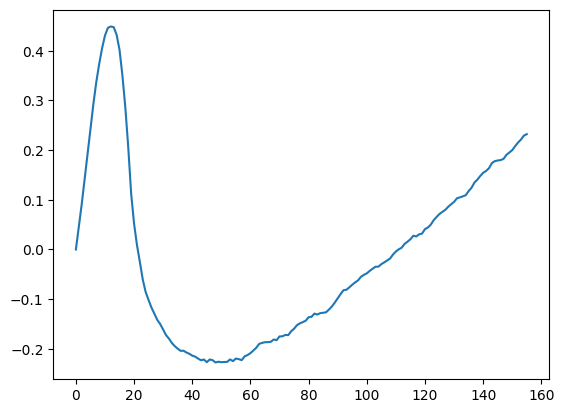

In [ ]:
plt.plot(dataset['Cycle'], dataset['Thickness (nm)'].values-hex_model(dataset['Cycle'].values, *popt_2))

In [ ]:
popt_2

array([0.0943699 , 0.09855665])

In [ ]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
def semihemi_model(cycles,
                   dr=.1, # Growth per cycle
                   R0_offset=1e-3, # difference between deposited curvature radius and contact radius
                   K=1, # Shape Factor applied to r^2 to find area
                   R_lim=10, #Rough maximum grain size
                   A0=100, # Total Area
                   return_areas=False):
    result = []
    areas = []

    for cycle in cycles:
        R_low = 0 + dr*cycle
        R0 = R0_offset + dr*cycle
        r = np.arange(0, R_low, dr) + dr
        N = r/np.sqrt(np.abs(R0**2 - r**2))
        frac_bound = np.zeros_like(r)
        frac_bound[r>R_lim] = 2*np.acos(R_lim/r[r>R_lim])/np.pi
        #perimeter_vs_r = K*N*frac_free

        volume = dr*np.sum((1-frac_bound)*N*K*r**2 + frac_bound*N*A0)
        result.append(volume/A0)
        base_area = min(A0, K*R_low**2)
        areas.append(base_area/A0)

    if return_areas:
        return np.array(result), np.array(areas)
    else:
        return np.array(result)


In [ ]:
#dataset = pd.read_csv('/content/drive/MyDrive/PSED Project/10_06_2025_10-59-11_simulation_data_155.0cy.csv', header=[0])
dataset = pd.read_csv('/content/drive/MyDrive/PSED Project/10_07_2025_19-37-31_simulation_data_155.0cy.csv', header=[0])
popt_3, pcov_3 = curve_fit(semihemi_model, dataset['Cycle'].values, dataset['Thickness (nm)'].values,
                        p0 = [.1, 5, np.pi, 10, 300], bounds=(0, np.inf))


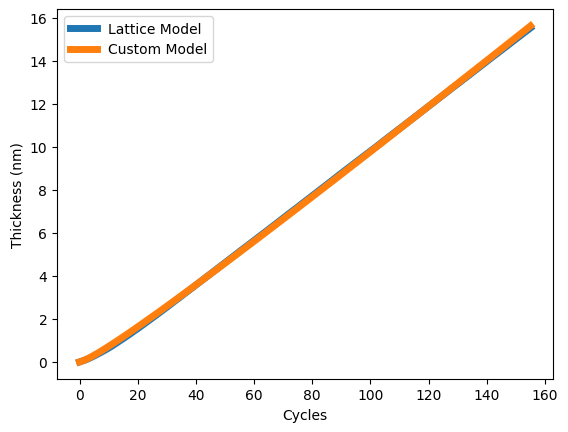

In [ ]:
plt.plot(dataset['Cycle'], dataset['Thickness (nm)'], label='Lattice Model', linewidth=5)
plt.plot(dataset['Cycle'], semihemi_model(dataset['Cycle'].values, *popt_3), label='Custom Model', linewidth=5)
plt.xlabel('Cycles')
plt.ylabel('Thickness (nm)')
plt.legend()
#print(popt_3)

In [ ]:
#dataset['Cycle'].values, np.linspace(0,100,100) #print(popt_3)

In [ ]:
th, sa = semihemi_model(dataset['Cycle'].values, *popt_3, True)

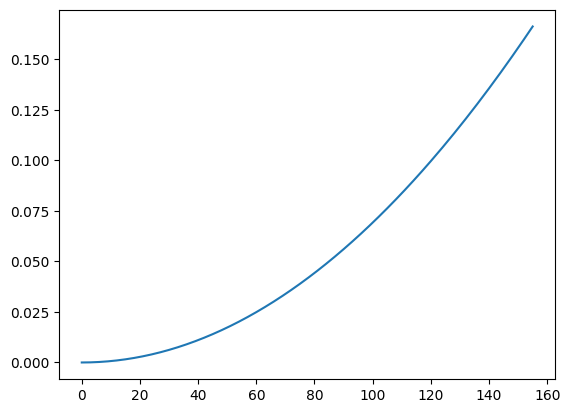

In [ ]:
plt.plot(dataset['Cycle'].values, sa)

In [ ]:
th, sa = semihemi_model(np.linspace(0,1000,101), *popt_3, True)

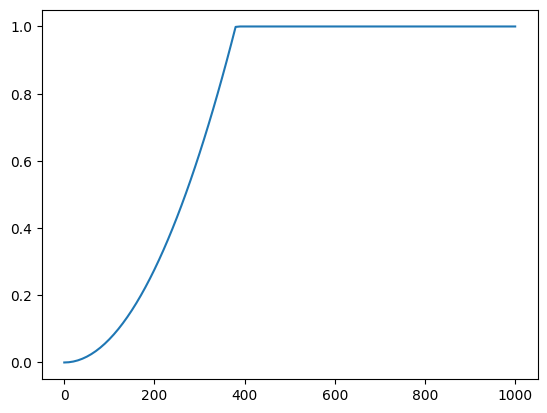

In [ ]:
plt.plot(np.linspace(0,1000,101), sa)

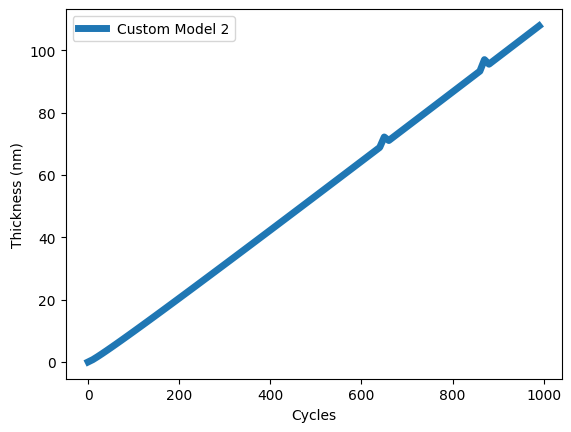

In [ ]:
#plt.plot(dataset['Cycle'], dataset['Thickness (nm)'], label='Lattice Model', linewidth=5)
#plt.plot(dataset['Cycle'], semihemi_model(dataset['Cycle'].values, *popt_3), label='Custom Model', linewidth=5)
plt.plot(np.arange(0,1000,10), semihemi_model(np.arange(0,1000,10), *popt_3), label='Custom Model 2', linewidth=5)
plt.xlabel('Cycles')
plt.ylabel('Thickness (nm)')
plt.legend()
#print(popt_3)

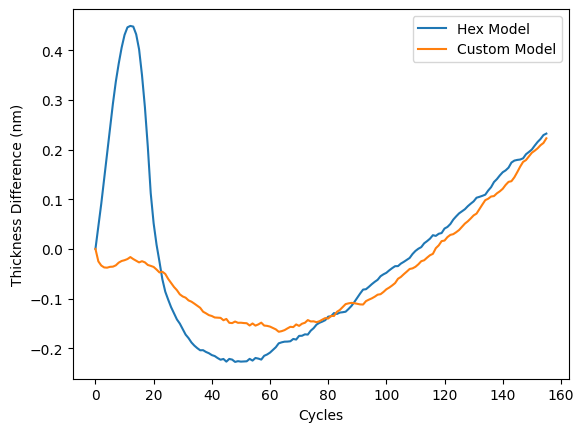

In [ ]:
plt.plot(dataset['Cycle'], dataset['Thickness (nm)'].values-hex_model(dataset['Cycle'].values, *popt_2), label='Hex Model')
plt.plot(dataset['Cycle'], semihemi_model(dataset['Cycle'].values, *popt_3)-dataset['Thickness (nm)'], label='Custom Model')
plt.xlabel('Cycles')
plt.ylabel('Thickness Difference (nm)')
plt.legend()


Text(0, 0.5, 'Thickness (nm)')

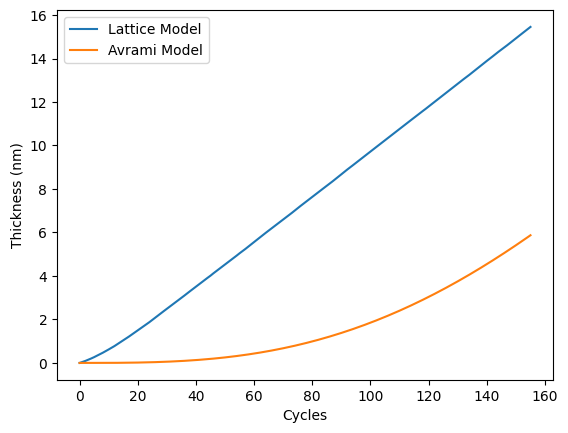

In [ ]:
plt.plot(dataset['Cycle'], dataset['Thickness (nm)'], label= 'Lattice Model')
plt.plot(dataset['Cycle'], avrami_model_2(dataset['Cycle'].values, *popt), label='Avrami Model')
plt.legend()
plt.xlabel('Cycles')
plt.ylabel('Thickness (nm)')


## Mixing algorithm

In [ ]:
def mixing_algo(h_traj, P_traj, P_parallel=None, a_window=20, beta=np.array([1, 0.2])):
    #P_traj [n * params]
    #P_parallel [sources * params]
    #beta = [1 + sources]

    if a_window > len(h_traj):
        a_window = len(h_traj)

    def h_traj_2_alpha(h_traj, scale=1.0):
        #alpha = np.exp(-h_traj[-a_window:]/scale)
        alpha = np.exp(np.arange(len(h_traj)-a_window, len(h_traj)) / scale)
        return alpha

    alpha = h_traj_2_alpha(h_traj)
    P_next = np.sum(P_traj[-a_window:]*(alpha/np.sum(alpha)))/a_window
    if P_parallel is not None:
        P_next = (beta[0]*P_next+beta[1:]*P_parallel)/np.sum(beta)

    return P_next

## Parameter Model

# Converted Models

## Hemisphere

In [ ]:
def hex_model(cycle, Nd = 0.04, delta_r=0.05):
    #t = np.linspace(0, 100, 100)
    #cycle = np.array(cycle)
    radius = cycle*delta_r
    Rcov = 1/np.sqrt(np.pi * Nd)
    #tcut = np.sum(r<Rcov)
    #result = np.zeros_like(cycle)
    lower = lambda r: 2/3 *np.pi*Nd*(r)**3
    upper = lambda r: Nd * (np.pi*(Rcov**2)*np.sqrt((r)**2 - Rcov**2)+np.pi/6*(3*Rcov**2+(r-np.sqrt(r**2-Rcov**2))**2)*(r-np.sqrt(r**2-Rcov**2)))
    if radius < Rcov:
        result = lower(radius)
    else:
        result = upper(radius)
    #result[radius < Rcov] = lower(radius[radius < Rcov])
    #result[radius >= Rcov] = upper(radius[radius >= Rcov])

    return result

## Semi-Hemi

In [ ]:
def semi_hemi_step( cycle,
                    dr=.1, # Growth per cycle
                    R0_offset=1e-3, # difference between deposited curvature radius and contact radius
                    K=1, # Shape Factor applied to r^2 to find area
                    R_lim=10, #Rough maximum grain size
                    A0=100, # Total Area
):
    R_low = 0 + dr*cycle
    R0 = R0_offset + dr*cycle
    r = np.arange(0, R_low, dr) + dr
    N = r/np.sqrt(np.abs(R0**2 - r**2))
    frac_bound = np.zeros_like(r)
    frac_bound[r>R_lim] = 2*np.acos(R_lim/r[r>R_lim])/np.pi
    #perimeter_vs_r = K*N*frac_free

    volume = dr*np.sum((1-frac_bound)*N*K*r**2 + frac_bound*N*A0)
    thickness = volume/A0 #result.append(volume/A0)
    base_area = min(A0, K*R_low**2)
    #areas.append(base_area/A0)
    coverage = base_area/A0
    return thickness, base_area

## Channel Profile

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
N0 = 6.22*10**23
k = 1.38*10**-23 # Boltzmann constant
R = 8.314 # J/K.mol

In [ ]:
# #may be better fitting the 'd' values
# def d_estimate(MA, rho):
#     #rho here is the fluid/solid density of the molecule
#     return 2* np.pow(3*MA/(4*np.pi*rho*N0), 1/3)

# def za(da, db, MA, MB, pA, pB):
#     #find collision rate of a; (A+B) collisions and A+A collisions
#     #molecular diameter, molar mass, partial pressure
#     return (np.pi/4*((da+db)**2)*np.sqrt(8*R*T/np.pi*(1/MA + 1/MB)) * pB + np.pi * da**2 * np.sqrt(16*R*T/(np.pi*MA))*pA) /(R*T)

# def Deff(da, db, MA, MB, pA, pB):
#     z_a = za(da, db, MA, MB, pA, pB)
#     va = np.sqrt(8*R*T/(np.pi * MA))
#     Da = 3*np.pi/16 * va**2/z_a
#     Dkn = h*np.sqrt(8*R*T/(9*np.pi*MA))
#     Deff = 1/(1/Da + 1/Dkn)
#     return Deff

In [ ]:
class channelModel():

    def __init__(self):

        self.M = 101.96/1000 # kg/mol (molar mass of formula unit of film)
        self.rho = 3.99*1000 #density of film material

        self.b_film = 2 # number of metal atoms in the formula unit for the film
        self.b_a = 1 # number of metal atoms in the reactant, i.e. TMA
        self.c = 0.01 # c = sticking probability
        #self.Pd = 0 # Pd = Desorption probability
        self.da = 591e-12 #tma #d_estimate()
        self.db = 418e-12 #water #d_estimate()
        # Molar Mass
        self.MA = 72.09e-3 #kg/mol
        self.MB = 18e-3

        # Channel Geometry
        self.H = 0.2e-6
        self.W = 0.1e-3

        self.gpc = 106 * 10**-12 # gpc (m)
        self.K = 100 # equilibrium constant for langmuir model
        # or K = cQ/(qP_d)
        # But they seem to generally give K as its own value
        # c is used for calculating the delimiter instead

        self.T = 300 + 273 # Temperature
        self.t_p = 0.1 #pulse time

        self.pA = 100 #*1e-3 # Partial Pressure of reactant A (limiting diffusion)
        #self.pA0 = self.pA
        self.pB = 300 # partial pressure of reactant B

    def calc_hydro_diameter(self):
        self.h = 2/(1/self.H + 1/self.W)
    def calc_adsorption_density(self):
        self.q = (self.b_film/self.b_a) * (self.rho*self.gpc/self.M) * N0 #TMA q (adsorption density)
    def collision_rate(self):
        self.Q = N0/np.sqrt(2*np.pi* self.M * R * self.T)# Q: collision rate at unit pressure

    def calc_za(self):
        #find collision rate of a; (A+B) collisions and A+A collisions
        #molecular diameter, molar mass, partial pressure
        self.za = (np.pi/4*((self.da+self.db)**2)*np.sqrt(8*R*self.T/np.pi*(1/self.MA + 1/self.MB)) * self.pB + \
                   np.pi * self.da**2 * np.sqrt(16*R*self.T/(np.pi*self.MA))*self.pA) /(R*self.T)
    def calc_Deff(self):
        z_a = self.za #(self.da, self.db, self.MA, self.MB, self.pA, self.pB)
        va = np.sqrt(8*R*self.T/(np.pi * self.MA))
        Da = 3*np.pi/16 * va**2/z_a
        Dkn = self.h*np.sqrt(8*R*self.T/(9*np.pi*self.MA))
        self.Deff = 1/(1/Da + 1/Dkn)

    def approx(self, x, last_theta):

        D = self.pA*self.Deff*self.H/(self.q*k*self.T*(1-np.log(self.K*self.pA+1)/(self.K*self.pA)))
        xs = np.sqrt(D*self.t_p)
        delim = np.sqrt((self.h*N0*self.Deff)/(4*R*self.T*self.c*self.Q))
        xt = xs-delim #np.max(0.0, xs-delim)
        if xt < 0:
            xt = 0
        pt = self.pA * (1-xt/xs)
        pA = self.pA * (1-x/xs)
        pA[x>xt] = pt*np.exp(-(x[x>xt]-xt)/(xs-xt))

        theta = (self.K*pA)/(1+self.K*pA)

        next_theta = last_theta + theta

        thickness = self.gpc*next_theta

        #print('xt: ', xt)

        return thickness, next_theta, {'theta':theta, 'pA': pA}

    def run(self, steps, initial_x):

        results = []#pd.DataFrame()

        #Assuming no temperature change, these don't need recalculation
        self.collision_rate()
        self.calc_adsorption_density()
        self.calc_za()
        last_theta = initial_x.copy()

        original_H = self.H

        for step in range(steps):
            self.calc_hydro_diameter()
            self.calc_Deff()
            thickness, last_theta, intermediates = self.approx(x, last_theta)
            results.append(pd.DataFrame({'thickness': thickness} | intermediates))
            self.H = self.H - 2 * self.gpc

        self.H = original_H

        results = pd.concat(results, keys=range(steps))
        return results




In [ ]:
model = channelModel()
#model.pA *= 2
model.t_p*=10
model.H = 0.5* 0.2e-6
model.W = 1000*0.2e-6

In [ ]:
x = np.linspace(0, 200e-6, 100)
result = model.run(100, x)

In [ ]:
#result#['thickness'].values


In [ ]:
# plt.plot(x, result['thickness'][19])
# plt.plot(x, result['thickness'][39])
# plt.plot(x, result['thickness'][59])
# plt.plot(x, result['thickness'][79])
# plt.plot(x, result['thickness'][99])

# plt.plot(x, model.H-result['thickness'][19])
# plt.plot(x, model.H-result['thickness'][39])
# plt.plot(x, model.H-result['thickness'][59])
# plt.plot(x, model.H-result['thickness'][79])
# plt.plot(x, model.H-result['thickness'][99])
# plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

Text(0, 0.5, 'channel geometry')

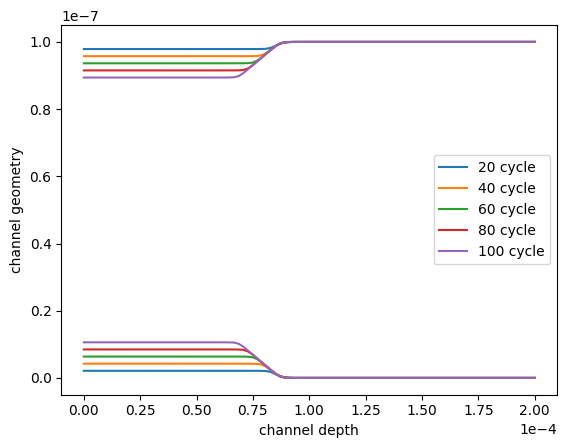

In [ ]:
for cycle in [20, 40, 60, 80, 100]:
    l1 = plt.plot(x, result['thickness'][cycle-1], label= f'{cycle} cycle')
    plt.plot(x, model.H-result['thickness'][cycle-1], color=l1[0].get_color())

plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.legend()
plt.xlabel('channel depth')
plt.ylabel('channel geometry')

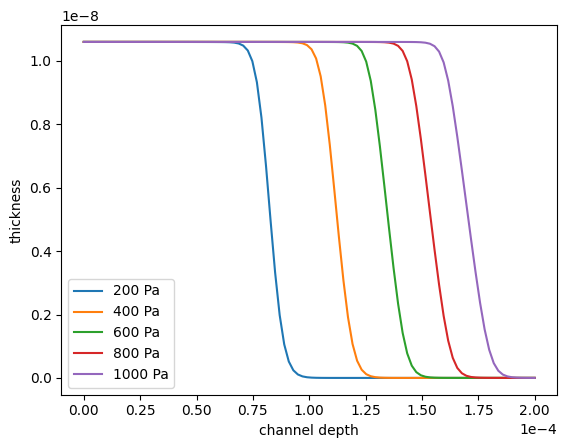

In [ ]:

for pressure in range(200, 1200, 200):
    model = channelModel()
    model.pA = pressure
    x = np.linspace(0, 200e-6, 100)
    result = model.run(100, x)
    plt.plot(x, result['thickness'][99], label=f'{pressure} Pa')
plt.legend()
plt.ylabel('thickness')
plt.xlabel('channel depth')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

for tp in [0.05, 0.1, 0.2, 0.5, 1.0]:

    model = channelModel()
    model.t_p = tp   # 🔴 pulse time 변경

    x = np.linspace(0, 200e-6, 100)

    result = model.run(100, x)

    plt.plot(x, result['thickness'][99], label=f'{tp} s')

plt.legend()
plt.ylabel('thickness')
plt.xlabel('channel depth')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.title('Thickness vs Pulse Time')
plt.show()

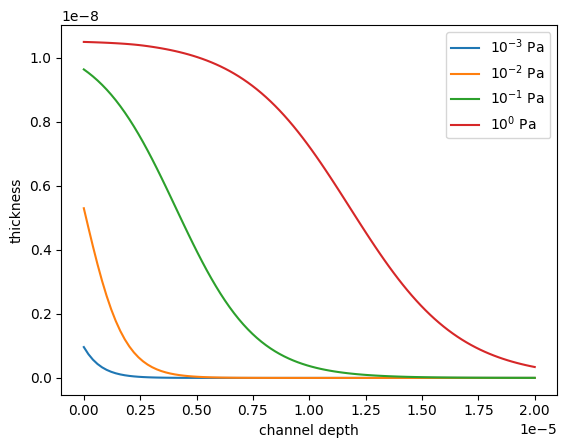

In [ ]:

for pressure in range(-3, 1):
    model = channelModel()
    model.pA = 10**(pressure)
    x = np.linspace(0, 20e-6, 100)
    result = model.run(100, x)
    plt.plot(x, result['thickness'][99], label='$10^{'+f'{pressure}'+'}$ Pa')
plt.legend()
plt.ylabel('thickness')
plt.xlabel('channel depth')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

Text(0.5, 0, 'channel depth')

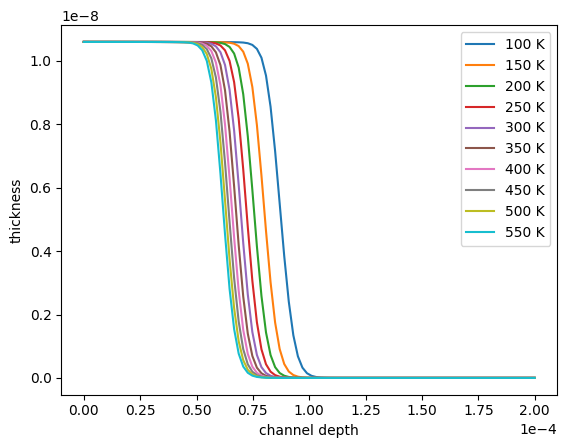

In [ ]:

for temperature in range(100, 600, 50):
    model = channelModel()
    model.T = temperature
    x = np.linspace(0, 200e-6, 100)
    result = model.run(100, x)
    plt.plot(x, result['thickness'][99], label=f'{temperature} K')
plt.legend()
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.ylabel('thickness')
plt.xlabel('channel depth')

Text(0, 0.5, 'pressure')

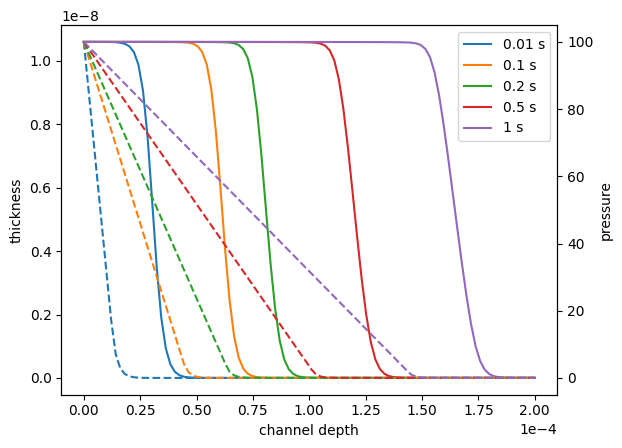

In [ ]:
ax1 = plt.gca()
ax2 = ax1.twinx()

for time in [.01, .1, .2, .5, 1]:
    model = channelModel()
    model.t_p = time
    x = np.linspace(0, 200e-6, 100)
    result = model.run(100, x)
    p1 = ax1.plot(x, result['thickness'][99], label=f'{time} s')
    ax2.plot(x, result['pA'][99], color = p1[0].get_color(), linestyle='--')
ax1.legend()
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax1.set_ylabel('thickness')
ax1.set_xlabel('channel depth')
ax2.set_ylabel('pressure')

Text(0.5, 0, 'channel depth')

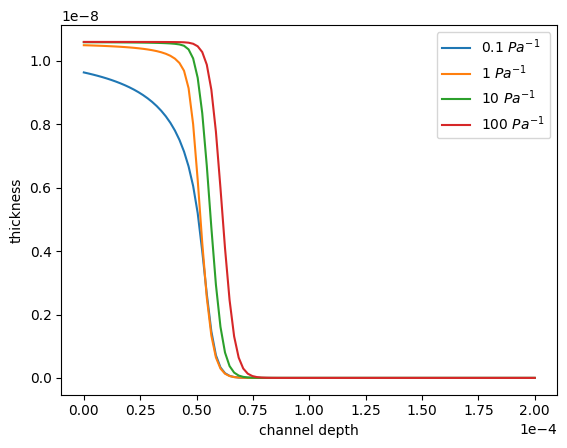

In [ ]:

for ads_const in [.1, 1, 10, 100]:
    model = channelModel()
    model.K = ads_const
    x = np.linspace(0, 200e-6, 100)
    result = model.run(100, x)
    plt.plot(x, result['thickness'][99], label=f'{ads_const} '+'$Pa^{-1}$')
plt.legend()
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.ylabel('thickness')
plt.xlabel('channel depth')